# Le Langage des Machines - Acte VI
## Les Transformers : BERT, GPT et l'Attention

**Glorie M. WOWO** | Data Scientist / EdTech Entrepreneur

---

Dans les actes precedents :
- **Acte I-IV** : BoW, TF-IDF, Naive Bayes, N-grammes
- **Acte V** : Word Embeddings (un vecteur fixe par mot)

**Probleme** : "avocat" a le meme vecteur dans "Je mange un avocat" et "Mon avocat plaide".

**Solution** : Les Transformers donnent un vecteur DIFFERENT selon le contexte !

## 1. Installation

In [ ]:
# Installation (a executer une seule fois)
# !pip install transformers torch sentencepiece

In [5]:
import warnings
warnings.filterwarnings('ignore')

from transformers import pipeline, AutoTokenizer, AutoModel
import torch
import numpy as np

print("[OK] Bibliotheques chargees")

[OK] Bibliotheques chargees


## 2. Le probleme : "avocat" dans deux contextes

In [6]:
phrase1 = "Je mange un avocat au dejeuner"
phrase2 = "Mon avocat plaide mon dossier"

print("=== Le probleme ===")
print(f"Phrase 1 : {phrase1}")
print(f"  --> avocat = FRUIT")
print(f"\nPhrase 2 : {phrase2}")
print(f"  --> avocat = METIER")
print("\nAvec les Word Embeddings : meme vecteur pour les deux !")
print("Avec les Transformers : vecteurs DIFFERENTS !")

=== Le probleme ===
Phrase 1 : Je mange un avocat au dejeuner
  --> avocat = FRUIT

Phrase 2 : Mon avocat plaide mon dossier
  --> avocat = METIER

Avec les Word Embeddings : meme vecteur pour les deux !
Avec les Transformers : vecteurs DIFFERENTS !


## 3. Utiliser un modele Transformer (CamemBERT)

CamemBERT est un modele BERT entraine sur du texte francais.

In [7]:
# Charger CamemBERT (modele francais)
print("Chargement de CamemBERT...")
tokenizer = AutoTokenizer.from_pretrained("camembert-base")
model = AutoModel.from_pretrained("camembert-base")
print("[OK] Modele charge !")

Chargement de CamemBERT...
[OK] Modele charge !


In [8]:
def get_word_embedding(phrase, mot_cible):
    """
    Obtient l'embedding contextuel d'un mot dans une phrase.
    """
    # Tokenizer
    inputs = tokenizer(phrase, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    
    # Trouver l'indice du mot cible
    mot_idx = None
    for i, token in enumerate(tokens):
        if mot_cible.lower() in token.lower():
            mot_idx = i
            break
    
    if mot_idx is None:
        print(f"Mot '{mot_cible}' non trouve dans les tokens: {tokens}")
        return None
    
    # Obtenir les embeddings
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Embedding du mot cible (derniere couche)
    embedding = outputs.last_hidden_state[0, mot_idx, :].numpy()
    
    return embedding, tokens

# Tester
emb1, tokens1 = get_word_embedding(phrase1, "avocat")
emb2, tokens2 = get_word_embedding(phrase2, "avocat")

print(f"Phrase 1 tokens : {tokens1}")
print(f"Phrase 2 tokens : {tokens2}")
print(f"\nDimensions des embeddings : {emb1.shape[0]}")

Phrase 1 tokens : ['<s>', '▁Je', '▁mange', '▁un', '▁avocat', '▁au', '▁de', 'jeu', 'ner', '</s>']
Phrase 2 tokens : ['<s>', '▁Mon', '▁avocat', '▁plaid', 'e', '▁mon', '▁dossier', '</s>']

Dimensions des embeddings : 768


In [9]:
# Comparer les deux embeddings de "avocat"
from scipy.spatial.distance import cosine

similarite = 1 - cosine(emb1, emb2)

print("=== Comparaison des embeddings de 'avocat' ===")
print(f"\nPhrase 1 (fruit)  : 10 premieres valeurs = {emb1[:10].round(3)}")
print(f"Phrase 2 (metier) : 10 premieres valeurs = {emb2[:10].round(3)}")
print(f"\nSimilarite cosinus : {similarite:.3f}")
print("\n[i] Les vecteurs sont DIFFERENTS !")
print("    (Avec Word Embeddings, la similarite serait de 1.0)")

=== Comparaison des embeddings de 'avocat' ===

Phrase 1 (fruit)  : 10 premieres valeurs = [-0.085 -0.162  0.266 -0.171 -0.117  0.215 -0.041  0.01   0.082  0.089]
Phrase 2 (metier) : 10 premieres valeurs = [ 0.008 -0.202  0.337 -0.018 -0.067  0.171  0.181 -0.039  0.061 -0.023]

Similarite cosinus : 0.737

[i] Les vecteurs sont DIFFERENTS !
    (Avec Word Embeddings, la similarite serait de 1.0)


## 4. Les 3 matrices fondamentales : Query, Key, Value


Le mécanisme d'Attention repose sur 3 matrices :

| Matrice | Rôle | Analogie bibliothèque |
|---------|------|----------------------|
| **Q (Query)** | "Qu'est-ce que je cherche ?" | Votre question au bibliothécaire |
| **K (Key)** | "Voici ce que je peux offrir" | Les étiquettes sur les étagères |
| **V (Value)** | "Voici mon contenu réel" | Le contenu des livres |

**Formule** : `Attention(Q, K, V) = softmax(Q × K^T / √d) × V`

In [12]:
# Visualiser les matrices Q, K, V
def show_qkv(phrase):
    """Montre les dimensions des matrices Q, K, V pour une phrase."""
    inputs = tokenizer(phrase, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # Les embeddings de la dernière couche
    hidden_states = outputs.last_hidden_state

    print(f"Phrase : {phrase}")
    print(f"Tokens : {tokens}")
    print(f"\nDimensions :")
    print(f"  - Nombre de tokens : {len(tokens)}")
    print(f"  - Dimension cachée (d_model) : {hidden_states.shape[2]}")
    print(f"\nEn interne, pour chaque tête d'attention :")
    print(f"  - Q : [{len(tokens)} x 64]  (requêtes)")
    print(f"  - K : [{len(tokens)} x 64]  (clés)")
    print(f"  - V : [{len(tokens)} x 64]  (valeurs)")
    print(f"  - Attention : [{len(tokens)} x {len(tokens)}]  (scores)")

show_qkv("Je mange un avocat au déjeuner")

CamembertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Phrase : Je mange un avocat au déjeuner
Tokens : ['<s>', '▁Je', '▁mange', '▁un', '▁avocat', '▁au', '▁déjeuner', '</s>']

Dimensions :
  - Nombre de tokens : 8
  - Dimension cachée (d_model) : 768

En interne, pour chaque tête d'attention :
  - Q : [8 x 64]  (requêtes)
  - K : [8 x 64]  (clés)
  - V : [8 x 64]  (valeurs)
  - Attention : [8 x 8]  (scores)


## 5. Classification de sentiments avec BERT

In [13]:
# Pipeline de classification de sentiments
print("Chargement du modele de classification...")
classifier = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)
print("[OK] Modele charge !")

Chargement du modele de classification...


Device set to use cpu


[OK] Modele charge !


In [14]:
# Avis SUCCEED
avis = [
    "Ce cours est excellent, je recommande !",
    "Formation confuse et mal organisee",
    "Ce n'est pas mauvais du tout",  # Negation !
    "J'aurais aime que ce soit mieux explique",  # Conditionnel
    "Le formateur est un vrai avocat de la pedagogie",  # Metaphore
]

print("=== Classification des avis SUCCEED ===")
for texte in avis:
    result = classifier(texte)[0]
    # Convertir les etoiles en sentiment
    stars = int(result['label'].split()[0])
    sentiment = "POSITIF" if stars >= 4 else "NEGATIF" if stars <= 2 else "NEUTRE"
    print(f"\n\"{texte}\"")
    print(f"  --> {sentiment} ({result['label']}, confiance: {result['score']:.2f})")

=== Classification des avis SUCCEED ===

"Ce cours est excellent, je recommande !"
  --> POSITIF (5 stars, confiance: 0.79)

"Formation confuse et mal organisee"
  --> NEGATIF (2 stars, confiance: 0.50)

"Ce n'est pas mauvais du tout"
  --> POSITIF (5 stars, confiance: 0.41)

"J'aurais aime que ce soit mieux explique"
  --> NEUTRE (3 stars, confiance: 0.41)

"Le formateur est un vrai avocat de la pedagogie"
  --> POSITIF (5 stars, confiance: 0.47)


## 6. Generation de texte avec GPT-2

In [15]:
# Pipeline de generation
print("Chargement de GPT-2...")
generator = pipeline("text-generation", model="gpt2")
print("[OK] Modele charge !")

Chargement de GPT-2...


Device set to use cpu


[OK] Modele charge !


In [16]:
# Generer du texte
prompt = "The best way to learn machine learning is"

print(f"=== Generation de texte ===")
print(f"Prompt : \"{prompt}\"\n")

result = generator(
    prompt,
    max_length=50,
    num_return_sequences=2,
    do_sample=True,
    temperature=0.7
)

for i, seq in enumerate(result):
    print(f"Generation {i+1} :")
    print(f"  {seq['generated_text']}")
    print()

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Generation de texte ===
Prompt : "The best way to learn machine learning is"

Generation 1 :
  The best way to learn machine learning is to come up with something that could be used to help make your business even better.

If you've ever had the pleasure of working with a machine learning consultant, you'll find that as you learn, you become more aware of the problem you are solving.

By this process, you will be able to better understand the problem and how to solve it better.

How to get started

We'll start by understanding the concepts of learning and machine learning.

In the next section, we will show you how to start building your own machine learning solution.

The following examples are from Google's Android team.

How to Find the Machine Learning Platform

1) Download the Google Code

2) Download the Google Code

3) Open the Google Code

4) Read the code

5) Read the code

6) Read the code

7) Read the code

8) Read the code

9) Read the code

10) Read the code

11) Read 

## 7. Questions-Reponses avec BERT

In [17]:
# Pipeline Q&A
print("Chargement du modele Q&A...")
qa = pipeline("question-answering", model="deepset/roberta-base-squad2")
print("[OK] Modele charge !")

Chargement du modele Q&A...


Device set to use cpu


[OK] Modele charge !


In [19]:
# Contexte : description de SUCCEED
contexte = """
SUCCEED est une plateforme de formation en ligne creee par Glorie M. WOWO.
Elle propose des cours d'Informatique, Programmation et Intelligence Artificielle.
Les formations sont disponibles en francais et s'adressent aux debutants comme aux professionnels.
La plateforme a ete lancee en 2023 et compte plus de 5000 apprenants.
"""

questions = [
    "Qui a cree SUCCEED ?",
    "Quels cours sont proposes ?",
    "Combien d'apprenants utilisent la plateforme ?",
]

print("=== Questions-Reponses ===")
print(f"Contexte : {contexte.strip()[:100]}...\n")

for question in questions:
    result = qa(question=question, context=contexte)
    print(f"Q: {question}")
    print(f"R: {result['answer']} (confiance: {result['score']:.2f})")
    print()

=== Questions-Reponses ===
Contexte : SUCCEED est une plateforme de formation en ligne creee par Glorie M. WOWO.
Elle propose des cours d'...

Q: Qui a cree SUCCEED ?
R: Glorie M. WOWO (confiance: 0.05)

Q: Quels cours sont proposes ?
R: Informatique, Programmation et Intelligence Artificielle (confiance: 0.19)

Q: Combien d'apprenants utilisent la plateforme ?
R: plus de 5000 (confiance: 0.10)



## 8. Visualisation de l'Attention

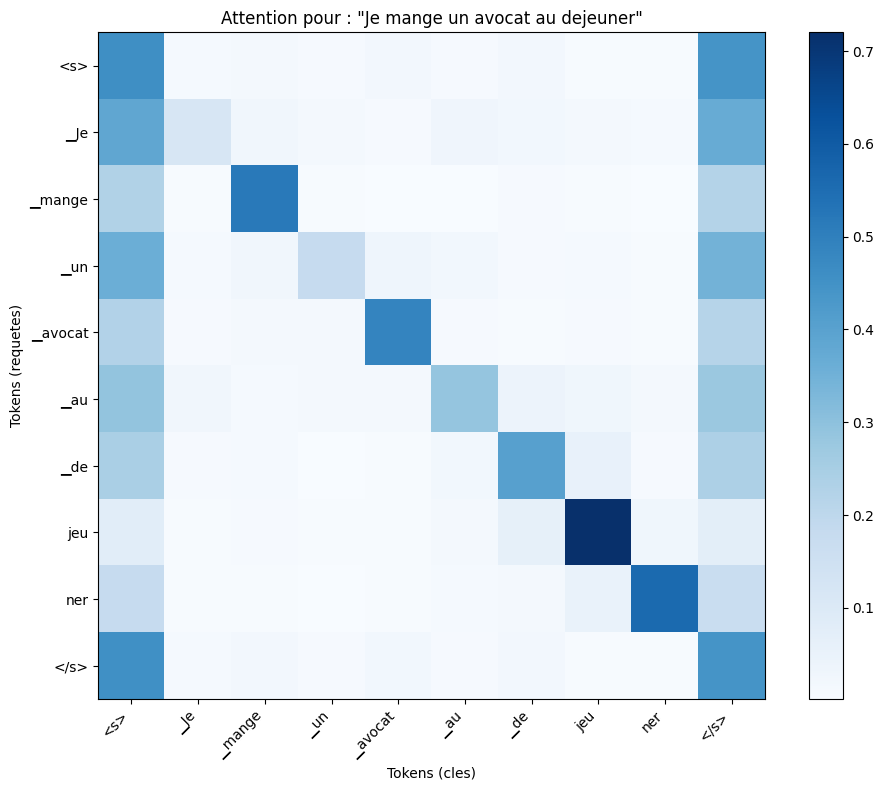


[i] Les cases foncees montrent ou le modele 'regarde'


In [20]:
import matplotlib.pyplot as plt

def visualize_attention(phrase):
    """
    Visualise les poids d'attention pour une phrase.
    """
    inputs = tokenizer(phrase, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    # Prendre la derniere couche, premiere tete
    attention = outputs.attentions[-1][0, 0].numpy()
    
    # Visualiser
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attention, cmap='Blues')
    
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right')
    ax.set_yticklabels(tokens)
    
    ax.set_xlabel('Tokens (cles)')
    ax.set_ylabel('Tokens (requetes)')
    ax.set_title(f'Attention pour : "{phrase}"')
    
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig('attention_map.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return attention, tokens

# Visualiser l'attention
attention, tokens = visualize_attention("Je mange un avocat au dejeuner")
print("\n[i] Les cases foncees montrent ou le modele 'regarde'")

##  Interpretation

La phrase analysée est : **"Je mange un avocat au déjeuner"**

Ce graphe est une **heatmap d'attention** : chaque case (i, j) représente
le poids d'attention que le token en **ligne** (requête) accorde au token
en **colonne** (clé). Plus la case est **foncée**, plus l'attention est élevée.

---

###  Ce que l'on observe

**1. La diagonale**  
Chaque token s'attend lui-même → comportement normal et attendu.  
Le modèle s'ancre d'abord sur sa propre position.

**2. Les tokens spéciaux `<s>` et `</s>`**  
Les cases foncées sur toute leur ligne et colonne montrent qu'ils
captent une attention forte sur l'ensemble de la séquence.  
→ Ils jouent le rôle de **résumé global** de la phrase.

**3. `_mange` (le verbe)**  
Il concentre une attention élevée sur lui-même.  
→ En tant que **pivot syntaxique**, il porte la structure de la phrase.

**4. `_déjeuner` (le complément)**  
Il reçoit de l'attention de plusieurs tokens voisins.  
→ Il ancre le **contexte temporel** de toute la phrase.

---

###  Pourquoi c'est important ?

> Un embedding statique (Word2Vec, Acte V) donnerait le **même vecteur**
> au mot *"avocat"* qu'il s'agisse d'un **fruit** 🥑 ou d'un **juriste** ⚖️.

Ici, grâce à l'attention, le modèle pondère les tokens *"mange"* et
*"déjeuner"* pour **désambiguïser** le sens du mot *"avocat"*.

C'est le principe fondamental des **représentations contextuelles**
introduites par les Transformers (Acte VI).

---

###  Résumé

| Observation | Interprétation |
|---|---|
| Diagonale foncée | Chaque token s'attend lui-même |
| `<s>` et `</s>` foncés | Capture du contexte global |
| `_mange` foncé | Verbe = pivot syntaxique |
| `_déjeuner` foncé | Ancrage du contexte de la phrase |

## 9. Recapitulatif

### Transformers vs Word Embeddings

| Aspect | Word Embeddings | Transformers |
|--------|-----------------|-------------|
| Vecteur | Fixe par mot | Contextuel |
| "avocat" | Meme vecteur | Different selon phrase |
| Negation | Mal geree | Bien comprise |
| Taille | Petit (300 dim) | Grand (768+ dim) |

### BERT vs GPT

| | BERT | GPT |
|--|------|-----|
| Direction | Bidirectionnel | Gauche a droite |
| Usage | Comprendre | Generer |
| Exemples | Classification, Q&A | Chatbots, redaction |

### Bibliotheques
- **Hugging Face Transformers** : pipeline facile a utiliser
- **CamemBERT** : BERT pour le francais

---



## 🌐 Sources gratuites et accessibles sur les tailles de paramètres

---

### Sites toujours gratuits

| Modèle | Source accessible | Lien |
|---|---|---|
| **BERT** | Page GitHub officielle Google | [github.com/google-research/bert](https://github.com/google-research/bert) |
| **CamemBERT** | Page Hugging Face du modèle | [huggingface.co/almanach/camembert-base](https://huggingface.co/almanach/camembert-base) |
| **GPT-2** | Annonce officielle OpenAI | [openai.com/index/better-language-models](https://openai.com/index/better-language-models/) |
| **GPT-4** | Technical Report OpenAI (PDF gratuit) | [arxiv.org/abs/2303.08774](https://arxiv.org/abs/2303.08774) |
| **LLaMA** | Paper Meta (PDF gratuit) | [arxiv.org/abs/2302.13971](https://arxiv.org/abs/2302.13971) |

---

### Astuce : Hugging Face comme source universelle

> Pour **n'importe quel modèle**, la page Hugging Face affiche
> directement le nombre de paramètres dans l'onglet **"Model card"**.
```
Exemples :
🔗 huggingface.co/google-bert/bert-base-uncased     → 110M params
🔗 huggingface.co/almanach/camembert-base           → 110M params  
🔗 huggingface.co/openai-community/gpt2             → 1.5B params
🔗 huggingface.co/meta-llama/Llama-2-7b             → 7B params
```

> Hugging Face est **la référence de facto** de la communauté NLP.  
> Toutes ces pages sont **gratuites, sans inscription**, et maintenues
> à jour par les équipes officielles des modèles.

---

### Pour aller plus loin : Wikipedia (FR)

> La page Wikipedia francophone de chaque modèle cite
> les paramètres avec sources :
```
🔗 fr.wikipedia.org/wiki/BERT_(modèle_de_langage)
🔗 fr.wikipedia.org/wiki/GPT-2
🔗 fr.wikipedia.org/wiki/LLaMA
```

> Idéal pour tes apprenants francophones !

---

### Rappel : arxiv.org est toujours gratuit

> Contrairement aux revues scientifiques classiques (Nature, IEEE...),  
> **arXiv est une archive ouverte** — tous les articles sont
> téléchargeables gratuitement en PDF, sans abonnement.

**Glorie M. WOWO** | Data Scientist / EdTech Entrepreneur